# Top-Mass Combination Tutorial

This tutorial builds the baseline LHC top-mass combination, studies its dependence on the error-on-error assigned to individual systematics, and repeats the analysis with a fictitious outlying measurement.

## Setup

The tutorial uses the public `gvm` interface together with NumPy and Matplotlib. All input and output paths are relative to the `notebooks/top-mass` directory.

In [1]:
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Latex

from gvm import GVMCombination
from gvm import build_input_data
from gvm import input_data
from gvm import plot_combination_summary


## Baseline LHC combination

We begin with the 15 published ATLAS and CMS measurements. This fit provides the reference result: every systematic uses its nominal variance, with no error-on-error assigned.

In [2]:
data = build_input_data('input_files/LHC_comb.yaml')

comb = GVMCombination(data)

comb.fit()
mu_hat         = comb.fit_results.mu
ci_low, ci_high, ci_half = comb.confidence_interval()
chi2           = comb.goodness_of_fit()
ndof           = comb.n_meas - 1

latex_str = rf"""
\[
  {{\large\textbf{{BLUE result}}}}\\[8pt]
  \boxed{{\quad
    \begin{{aligned}}
      \mathrm{{central\ value}}\,(m_t):\ &{mu_hat:.3f}\\[6pt]
      \mathrm{{confidence\ interval}}:\ &\pm{ci_half:.3f}\\[6pt]
      \chi^2/\mathrm{{NDOF}}:\ &{chi2:.2f}/{ndof}
    \end{{aligned}}
  \quad}}
\]
"""

display(Latex(latex_str))

/Users/enzocanonero/Documents/PhD/tesi-codice/errors-on-errors/top-combination/code3.0/src/gvm/config.py:208: UserWarning: Correlation matrix "ptmiss" asymmetric for measurements ATLAS 8 l+jets and ATLAS 8 all-had.: 0.36 vs 0.86
  warnings.warn(


<IPython.core.display.Latex object>

### Scan ε per systematic (dependent type)

To test the stability of the combination, we assign a dependent error-on-error to one systematic at a time. At each value of ε, the fit is repeated and both the central value and the half-width of the 68.3% confidence interval are recorded.

In [3]:
systematics = ['LHCbJES', 'btag', 'ME', 'LHCJES1', 'LHCJES2', 'method', 'CMSbHad', 'LHCrad']
eps_grid = np.linspace(0.0, 0.6, 7)

base_mu = comb.fit_results.mu
base_ci = comb.confidence_interval()[2]

cv = {s: [] for s in systematics}
ci = {s: [] for s in systematics}

for syst in systematics:
    info = comb.get_input_data(copy=True)
    info.uncertain_systematics.clear()
    info.eoe_type[syst] = 'dependent'
    for eps in eps_grid:
        info.uncertain_systematics.clear()
        if eps != 0.0:
            info.uncertain_systematics[syst] = eps
        comb.set_input_data(info)
        cv[syst].append(comb.fit_results.mu)
        ci[syst].append(comb.confidence_interval()[2])

/Users/enzocanonero/Documents/PhD/tesi-codice/errors-on-errors/top-combination/code3.0/src/gvm/combination.py:185: UserWarning: Negative eigenvalue -4.8319e-01 in systematic "btag"; adding 4.9319e-01 to diagonal for regularisation.
  warnings.warn(
/Users/enzocanonero/Documents/PhD/tesi-codice/errors-on-errors/top-combination/code3.0/src/gvm/combination.py:185: UserWarning: Negative eigenvalue -3.6380e-01 in systematic "LHCrad"; adding 3.7380e-01 to diagonal for regularisation.
  warnings.warn(


The first plot tracks the fitted top mass, while the second tracks its uncertainty. In both cases, the black dash-dotted line is the original zero-error-on-error result.

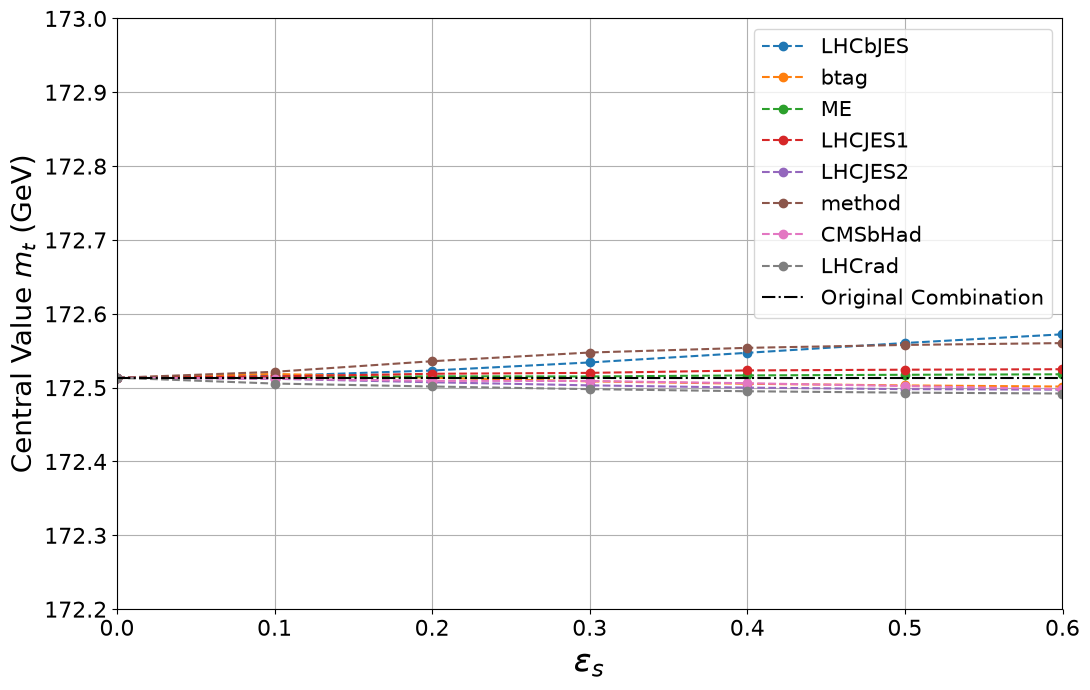

In [4]:
plt.figure(figsize=(11,7))
for s in systematics:
    plt.plot(eps_grid, cv[s], '--o', label=s)
plt.axhline(base_mu, color='black', linestyle='dashdot', label='Original Combination')
plt.xlabel(r'$\epsilon_s$', fontsize=24)
plt.ylabel('Central Value $m_t$ (GeV)', fontsize=20)
plt.xlim(0.0, 0.6)
plt.ylim(172.2, 173.)
plt.legend(fontsize=15)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

plt.savefig("output/central_values.png")
plt.show()

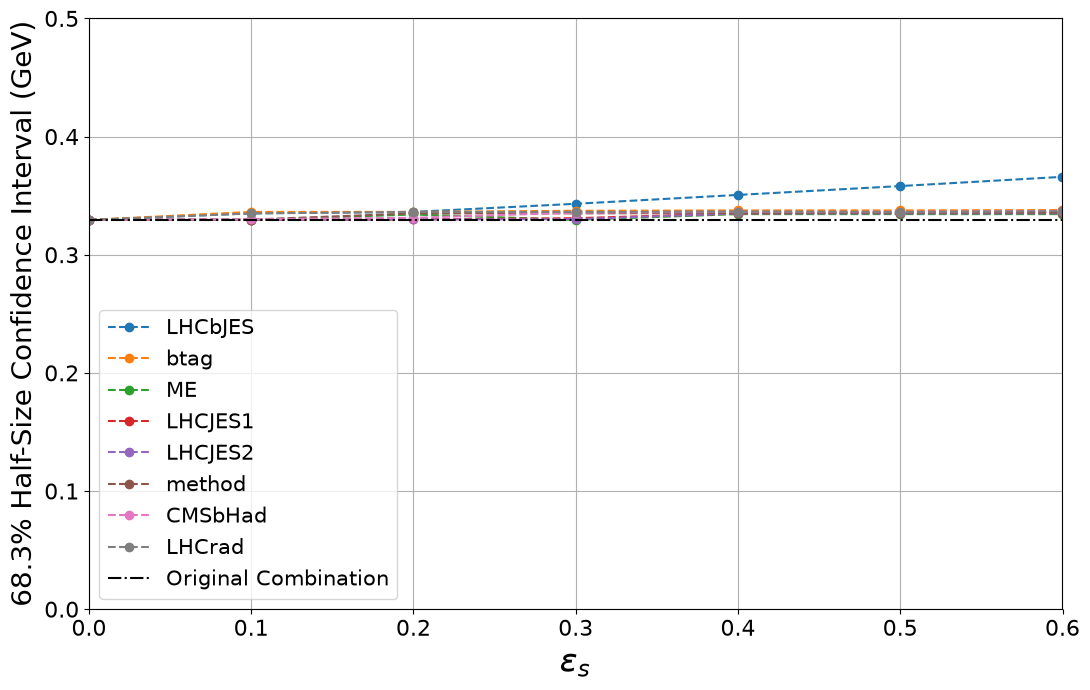

In [5]:
plt.figure(figsize=(11,7))
for s in systematics:
    plt.plot(eps_grid, ci[s], '--o', label=s)
plt.axhline(base_ci, color='black', linestyle='dashdot', label='Original Combination')
plt.xlabel(r'$\epsilon_s$', fontsize=24)
plt.ylabel(r'$68.3\%$ Half-Size Confidence Interval (GeV)', fontsize=20)
plt.xlim(0.0, 0.6)
plt.ylim(0., 0.5)
plt.legend(fontsize=15, loc='lower left')
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

plt.savefig("output/confidence_intervals.png")
plt.show()

Each curve varies one selected systematic at a time, with all other errors-on-errors set to zero. Across the range shown, the combined mass changes by less than about \(0.07\) GeV. `LHCbJES` gives the largest upward shift and the clearest interval broadening, while the other sources remain close to the original combination. This stability reflects the consistency and redundancy of the 15 input measurements.

## Combination with fictitious measurement

We now add the measurement labelled `new`, whose central value is deliberately high relative to the published inputs. The resulting fit shows how much leverage this outlier has when its systematic variance is treated as exact.

In [6]:
data = build_input_data('input_files/LHC_comb_fictitious_meas.yaml')

comb_fict = GVMCombination(data)

comb_fict.fit()
mu_hat = comb_fict.fit_results.mu
ci_low, ci_high, ci_half = comb_fict.confidence_interval()
chi2 = comb_fict.goodness_of_fit()
ndof = comb_fict.n_meas - 1

latex_str = rf"""
\[
  {{\large\textbf{{BLUE result}}}}\\[8pt]
  \boxed{{\quad
    \begin{{aligned}}
      \mathrm{{central\ value}}\,(m_t):\ &{mu_hat:.3f}\\[6pt]
      \mathrm{{confidence\ interval}}:\ &\pm{ci_half:.3f}\\[6pt]
      \chi^2/\mathrm{{NDOF}}:\ &{chi2:.2f}/{ndof}
    \end{{aligned}}
  \quad}}
\]
"""

display(Latex(latex_str))

<IPython.core.display.Latex object>

### Scan ε per systematic (dependent type, with NEW)

The same one-at-a-time scan is repeated after adding the outlier. Including `NEW` among the scanned systematics separates its response from that of the uncertainties already present in the baseline combination.

In [7]:
systematics = ['NEW', 'LHCbJES', 'btag', 'ME', 'LHCJES1', 'LHCJES2', 'method', 'CMSbHad', 'LHCrad']
eps_grid = np.linspace(0., 0.6, 7)

base_mu = comb_fict.fit_results.mu
base_ci = comb_fict.confidence_interval()[2]

cv_fict = {s: [] for s in systematics}
ci_fict = {s: [] for s in systematics}

for syst in systematics:
    info = comb_fict.get_input_data(copy=True)
    info.uncertain_systematics.clear()
    info.eoe_type[syst] = 'dependent'
    for eps in eps_grid:
        info.uncertain_systematics.clear()
        if eps != 0.0:
            info.uncertain_systematics[syst] = eps
        comb_fict.set_input_data(info)
        cv_fict[syst].append(comb_fict.fit_results.mu)
        ci_fict[syst].append(comb_fict.confidence_interval()[2])

As before, the upper plot follows the fitted mass and the lower plot follows the 68.3% interval half-width. The reference line now corresponds to the fit that includes `new` but has zero error-on-error.

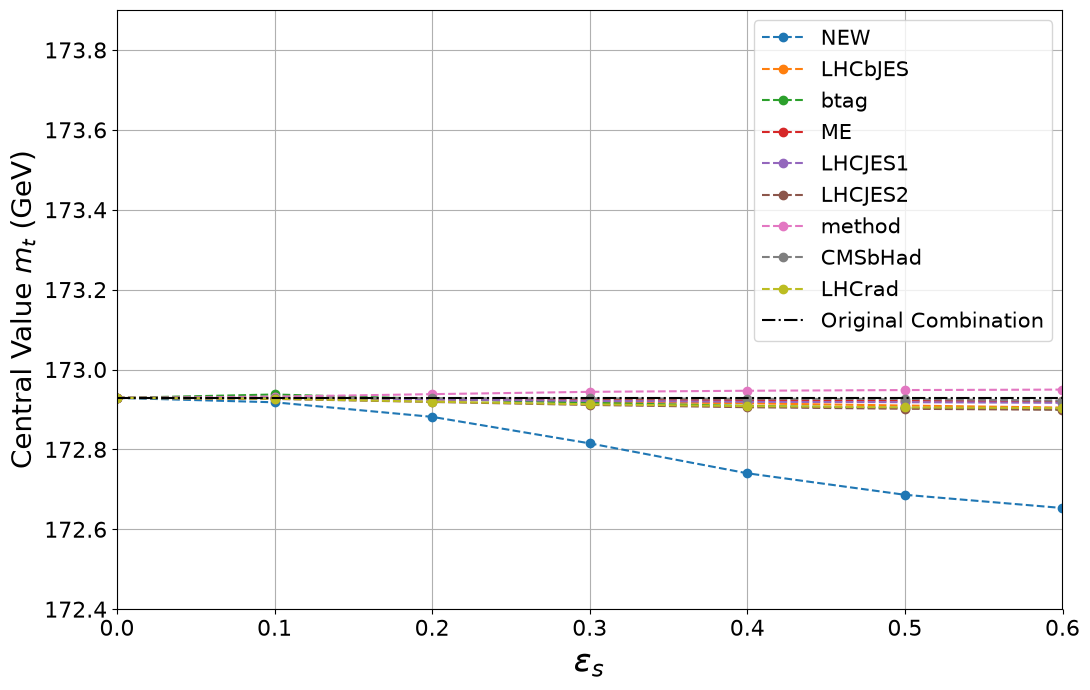

In [8]:
plt.figure(figsize=(11,7))
for s in systematics:
    plt.plot(eps_grid, cv_fict[s], '--o', label=s)
plt.axhline(base_mu, color='black', linestyle='dashdot', label='Original Combination')
plt.xlabel(r'$\epsilon_s$', fontsize=24)
plt.ylabel('Central Value $m_t$ (GeV)', fontsize=20)
plt.xlim(0.0, 0.6)
plt.ylim(172.4, 173.9)
plt.legend(fontsize=15)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

plt.savefig("output/central_values_fict.png")
plt.show()

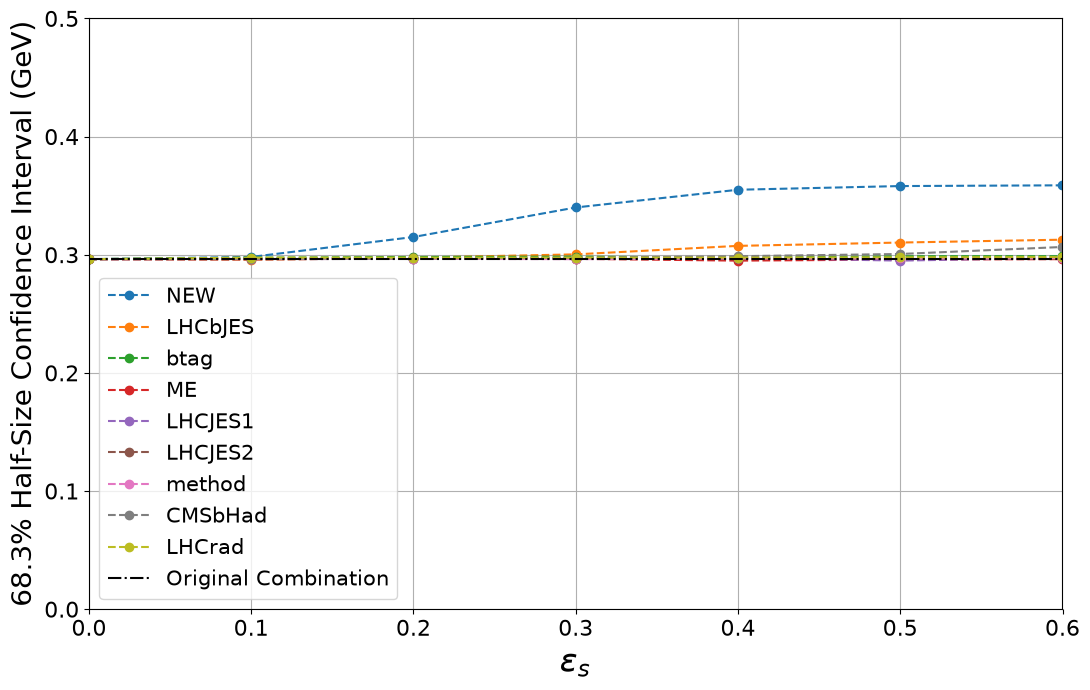

In [9]:
plt.figure(figsize=(11,7))
for s in systematics:
    plt.plot(eps_grid, ci_fict[s], '--o', label=s)
plt.axhline(base_ci, color='black', linestyle='dashdot', label='Original Combination')
plt.xlabel(r'$\epsilon_s$', fontsize=24)
plt.ylabel(r'$68.3\%$ Half-Size Confidence Interval (GeV)', fontsize=20)
plt.xlim(0.0, 0.6)
plt.ylim(0., 0.5)
plt.legend(fontsize=15, loc='lower left')
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()

plt.savefig("output/confidence_intervals_fict.png")
plt.show()

The response changes once the fictitious measurement is included. Varying `NEW` moves the fitted mass from about \(172.93\) GeV at $\epsilon_{\mathrm{NEW}}=0$ to $172.65$ GeV at $0.6$, toward the original 15-measurement result. Its 68.3% interval also broadens from about $0.30$ to $0.36$ GeV. `LHCbJES` has the next-largest effect, whereas the remaining sources change the result only slightly. The flattening at larger $\epsilon_{\mathrm{NEW}}$ shows the progressive saturation of the outlier down-weighting.

## Summary plots at the scan endpoints

The blue points use the nominal statistical and systematic uncertainties of each measurement, so their error bars do not change with epsilon. The coloured bands show the fitted 68.3% and 95.5% confidence intervals. The compact labels give the experiment, centre-of-mass energy in TeV, and final state; `new` denotes the fictitious measurement.

Each state below is fitted from a newly loaded configuration. We first clear all errors-on-errors, then apply the displayed value only to `NEW`. This prevents the scans above from affecting the comparison.

The first pair places the baseline fit beside the outlier fit at $\epsilon_{\mathrm{NEW}}=0$. Both panels use the same vertical scale, so the pull from `new` can be read directly.

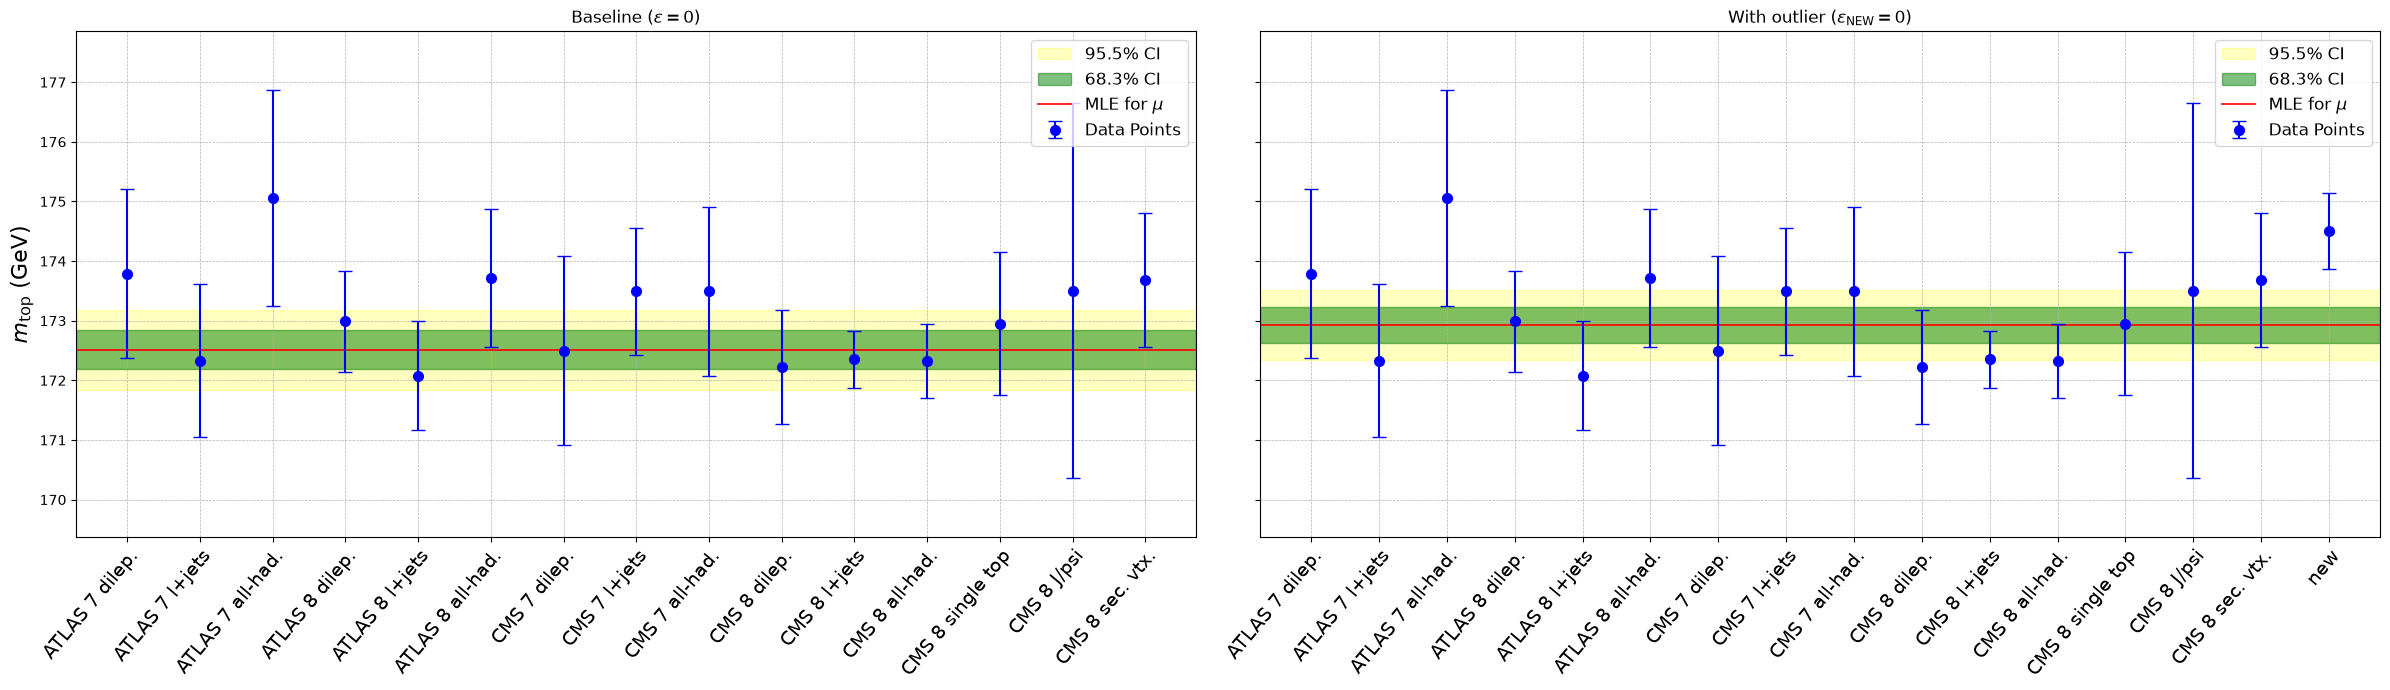

In [10]:
def fit_summary(
    config_path: str,
    new_epsilon: Optional[float] = None,
) -> tuple[input_data, float, tuple[float, float], tuple[float, float]]:
    summary_data = build_input_data(config_path)
    summary_data.uncertain_systematics.clear()
    if new_epsilon is not None and new_epsilon != 0.0:
        summary_data.uncertain_systematics['NEW'] = float(new_epsilon)

    summary_comb = GVMCombination(summary_data)
    summary_fit = summary_comb.fit()
    low_68, high_68, _ = summary_comb.confidence_interval(cl_val=0.683)
    low_95, high_95, _ = summary_comb.confidence_interval(cl_val=0.955)
    return summary_data, summary_fit.mu, (low_68, high_68), (low_95, high_95)


baseline_data, baseline_mu, baseline_ci_68, baseline_ci_95 = fit_summary(
    'input_files/LHC_comb.yaml'
)
outlier_zero_data, outlier_zero_mu, outlier_zero_ci_68, outlier_zero_ci_95 = fit_summary(
    'input_files/LHC_comb_fictitious_meas.yaml',
    new_epsilon=0.0,
)
outlier_high_data, outlier_high_mu, outlier_high_ci_68, outlier_high_ci_95 = fit_summary(
    'input_files/LHC_comb_fictitious_meas.yaml',
    new_epsilon=0.6,
)

fig, axes = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
plot_combination_summary(
    axes[0],
    baseline_data,
    baseline_mu,
    baseline_ci_68,
    baseline_ci_95,
    title=r'Baseline ($\epsilon=0$)',
    ylabel=r'$m_{\mathrm{top}}$ (GeV)',
    label_rotation=50,
)
plot_combination_summary(
    axes[1],
    outlier_zero_data,
    outlier_zero_mu,
    outlier_zero_ci_68,
    outlier_zero_ci_95,
    title=r'With outlier ($\epsilon_{\mathrm{NEW}}=0$)',
    ylabel='',
    label_rotation=50,
)
fig.tight_layout()
fig.savefig('output/top_mass_baseline_vs_outlier.png', dpi=150)
plt.show()

At zero error-on-error, adding `new` pulls the combined mass upward. The next pair keeps the same inputs in both panels and changes only $\epsilon_{\mathrm{NEW}}$ from 0 to 0.6; every other error-on-error remains zero.

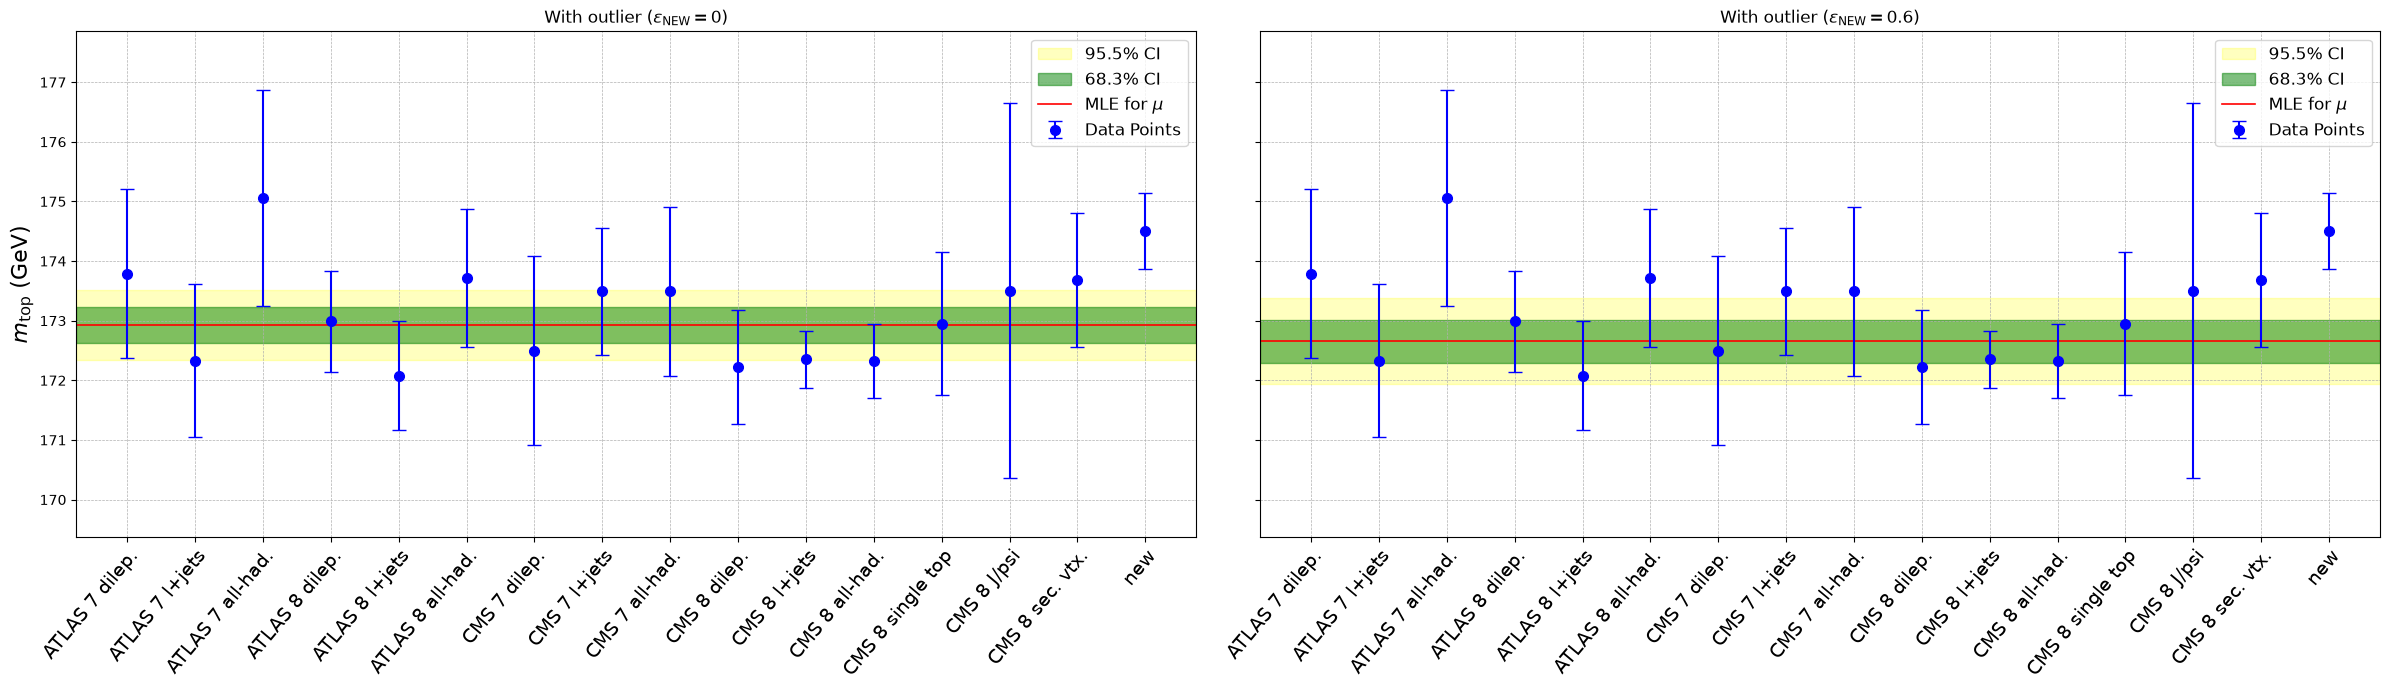

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7), sharey=True)
plot_combination_summary(
    axes[0],
    outlier_zero_data,
    outlier_zero_mu,
    outlier_zero_ci_68,
    outlier_zero_ci_95,
    title=r'With outlier ($\epsilon_{\mathrm{NEW}}=0$)',
    ylabel=r'$m_{\mathrm{top}}$ (GeV)',
    label_rotation=50,
)
plot_combination_summary(
    axes[1],
    outlier_high_data,
    outlier_high_mu,
    outlier_high_ci_68,
    outlier_high_ci_95,
    title=r'With outlier ($\epsilon_{\mathrm{NEW}}=0.6$)',
    ylabel='',
    label_rotation=50,
)
fig.tight_layout()
fig.savefig('output/top_mass_outlier_epsilon.png', dpi=150)
plt.show()

Increasing $\epsilon_{\mathrm{NEW}}$ reduces the influence of the outlier on the combined estimate while changing the fitted confidence intervals. The nominal error bar of `new` remains unchanged because epsilon describes uncertainty in its systematic variance, not a replacement input uncertainty.